In [15]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Load Function 4 data
X = np.load("function4/initial_inputs.npy")
Y = np.load("function4/initial_outputs.npy")
print("X shape:", X.shape)
print("Y shape:", Y.shape)


print(X)


print(Y)

X shape: (30, 4)
Y shape: (30,)
[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33

In [16]:
best_index = np.argmax(Y)
print("Best index:", best_index)
print("Best current x:", X[best_index])
print("Best current y:", Y[best_index])
print("Best current portal format:", "-".join(f"{v:.6f}" for v in X[best_index]))

kernel = C(1.0) * RBF(length_scale=0.2)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=True,
    random_state=42
)

gp.fit(X, Y)

rng = np.random.default_rng(42)
candidates = rng.uniform(0, 1, size=(10000, X.shape[1]))

mean, std = gp.predict(candidates, return_std=True)

kappa = 2.5
ucb = mean + kappa * std

best_ucb_index = np.argmax(ucb)
query = candidates[best_ucb_index]

print("Suggested query:", query)
print("Portal format:", "-".join(f"{v:.6f}" for v in query))
print("Predicted mean:", mean[best_ucb_index])
print("Predicted std:", std[best_ucb_index])
print("UCB score:", ucb[best_ucb_index])

Best index: 27
Best current x: [0.57776561 0.42877174 0.42582587 0.24900741]
Best current y: -4.025542281908162
Best current portal format: 0.577766-0.428772-0.425826-0.249007
Suggested query: [0.37036846 0.42165623 0.37170112 0.44789854]
Portal format: 0.370368-0.421656-0.371701-0.447899
Predicted mean: -1.3566908096824566
Predicted std: 0.624330273276118
UCB score: 0.20413487350783832


In [17]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
#For Function 4, I used Expected Improvement because Week 1 produced a much stronger best value. EI selected a point near the new best region, with small changes across the four inputs.
#This made sense because the updated data suggested this area was promising, so I wanted to test whether it could improve further rather than moving back to broad exploration.
# Load original Function 4 data
X = np.load("function4/initial_inputs.npy")
Y = np.load("function4/initial_outputs.npy")

# Add Week 1 query and output
week1_x = np.array([[0.370368, 0.421656, 0.371701, 0.447899]])
week1_y = np.array([0.17319018408919762])

X = np.vstack([X, week1_x])
Y = np.append(Y, week1_y)

print("Updated X shape:", X.shape)
print("Updated Y shape:", Y.shape)

print("Best current x:", X[np.argmax(Y)])
print("Best current y:", np.max(Y))

# Fit GP surrogate model
kernel = C(1.0) * RBF(length_scale=0.2)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=True,
    random_state=42
)

gp.fit(X, Y)

# Generate candidate points
rng = np.random.default_rng(42)
candidates = rng.uniform(0, 1, size=(10000, X.shape[1]))

# Predict mean and uncertainty
mean, std = gp.predict(candidates, return_std=True)

# Expected Improvement acquisition
y_best = np.max(Y)
std_safe = std + 1e-12

improvement = mean - y_best
z = improvement / std_safe
ei = improvement * norm.cdf(z) + std_safe * norm.pdf(z)

best_ei_index = np.argmax(ei)
query = candidates[best_ei_index]

print("Acquisition used: Expected Improvement")
print("Suggested query:", query)
print("Portal format:", "-".join(f"{v:.6f}" for v in query))
print("Predicted mean:", mean[best_ei_index])
print("Predicted std:", std[best_ei_index])
print("EI score:", ei[best_ei_index])

Updated X shape: (31, 4)
Updated Y shape: (31,)
Best current x: [0.370368 0.421656 0.371701 0.447899]
Best current y: 0.17319018408919762
Acquisition used: Expected Improvement
Suggested query: [0.41374232 0.47018227 0.29030926 0.4398533 ]
Portal format: 0.413742-0.470182-0.290309-0.439853
Predicted mean: -0.21047757372927478
Predicted std: 0.45221755954229914
EI score: 0.04987306022557966


In [18]:
import numpy as np
from scipy.stats import norm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C


# For Function 4, Week 2 performed much worse than Week 1.
# Because Week 1 remains the strongest observed region, I moved away from broad/global exploration
# and used a local hybrid EI-UCB strategy around the current best point.
# EI focuses on improving over the current best value, while UCB keeps a small uncertainty-aware component.


# -----------------------------
# Load original Function 4 data
# -----------------------------
X = np.load("function4/initial_inputs.npy")
Y = np.load("function4/initial_outputs.npy")


# -----------------------------
# Add Week 1 and Week 2 results
# -----------------------------


week2_x = np.array([[0.413742, 0.470182, 0.290309, 0.439853]])
week2_y = np.array([-1.7902558622959037])

X = np.vstack([X, week1_x, week2_x])
Y = np.append(Y, [week1_y[0], week2_y[0]])


print("Updated X shape:", X.shape)
print("Updated Y shape:", Y.shape)

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("Best current x:", best_x)
print("Best current y:", best_y)


# -----------------------------
# Fit GP surrogate model
# -----------------------------
kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(length_scale=np.ones(X.shape[1]) * 0.2, length_scale_bounds=(1e-2, 1.0), nu=2.5)
    + WhiteKernel(noise_level=1e-8, noise_level_bounds=(1e-10, 1e-3))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gp.fit(X, Y)

print("Fitted kernel:", gp.kernel_)


# -----------------------------
# Generate candidate points
# -----------------------------
rng = np.random.default_rng(42)
dim = X.shape[1]

# Function 4 has a clear best region from Week 1, while Week 2 got worse.
# So use mostly local candidates around the best point.
local_candidates = rng.normal(loc=best_x, scale=0.07, size=(25000, dim))
local_candidates = np.clip(local_candidates, 0, 1)

# Add a smaller global pool so the model can still consider alternatives.
global_candidates = rng.uniform(0, 1, size=(5000, dim))

candidates = np.vstack([local_candidates, global_candidates])


# -----------------------------
# Predict mean and uncertainty
# -----------------------------
mean, std = gp.predict(candidates, return_std=True)

y_best = np.max(Y)
std_safe = std + 1e-12


# -----------------------------
# Expected Improvement
# -----------------------------
improvement = mean - y_best
z = improvement / std_safe
ei = improvement * norm.cdf(z) + std_safe * norm.pdf(z)


# -----------------------------
# Upper Confidence Bound
# -----------------------------
# Keep kappa modest because Week 1 already gave a useful positive result,
# and Week 2 showed that moving too far away can perform badly.
kappa = 1.2
ucb = mean + kappa * std


# -----------------------------
# Strict filtered local hybrid EI-UCB
# -----------------------------
# Only consider candidates that are predicted to be reasonably competitive.
# This prevents uncertainty from dominating and selecting a point predicted to be poor.
mean_filter = mean >= (y_best - 0.10)

# Fallback in case the filter is too strict
if np.sum(mean_filter) == 0:
    mean_filter = mean >= np.percentile(mean, 90)

filtered_candidates = candidates[mean_filter]
filtered_mean = mean[mean_filter]
filtered_std = std[mean_filter]
filtered_ei = ei[mean_filter]
filtered_ucb = ucb[mean_filter]

ei_norm = (filtered_ei - np.min(filtered_ei)) / (np.max(filtered_ei) - np.min(filtered_ei) + 1e-12)
ucb_norm = (filtered_ucb - np.min(filtered_ucb)) / (np.max(filtered_ucb) - np.min(filtered_ucb) + 1e-12)

# EI is weighted more heavily because Function 4 has a known promising region.
hybrid_score = 0.75 * ei_norm + 0.25 * ucb_norm

best_hybrid_index = np.argmax(hybrid_score)
query = filtered_candidates[best_hybrid_index]


# -----------------------------
# Output results
# -----------------------------
print("Acquisition used: Strict filtered local Hybrid EI + UCB")
print("Number of candidates passing filter:", np.sum(mean_filter))
print("Suggested query:", query)

print("Portal format with hyphens:")
print("-".join(f"{v:.6f}" for v in query))

print("Portal format with x labels:")
print(",".join(f"x{i+1}:{v:.6f}" for i, v in enumerate(query)))

print("Predicted mean:", filtered_mean[best_hybrid_index])
print("Predicted std:", filtered_std[best_hybrid_index])
print("EI score:", filtered_ei[best_hybrid_index])
print("UCB score:", filtered_ucb[best_hybrid_index])
print("Hybrid score:", hybrid_score[best_hybrid_index])

Updated X shape: (32, 4)
Updated Y shape: (32,)
Best current x: [0.370368 0.421656 0.371701 0.447899]
Best current y: 0.17319018408919762
Fitted kernel: 1.72**2 * Matern(length_scale=[1, 0.972, 0.924, 0.979], nu=2.5) + WhiteKernel(noise_level=2.11e-10)
Acquisition used: Strict filtered local Hybrid EI + UCB
Number of candidates passing filter: 2562
Suggested query: [0.37902776 0.41091269 0.44705438 0.44225466]
Portal format with hyphens:
0.379028-0.410913-0.447054-0.442255
Portal format with x labels:
x1:0.379028,x2:0.410913,x3:0.447054,x4:0.442255
Predicted mean: 0.6329495878934246
Predicted std: 0.3322912392289332
EI score: 0.472390634462461
UCB score: 1.0316990749681445
Hybrid score: 0.985800802909551


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [19]:
# week 4 

week3_x = np.array([[0.379028, 0.410913, 0.447054, 0.442255]])
week3_y = np.array([-0.06479142792096892])

X = np.vstack([X, week1_x, week2_x, week3_x])
Y = np.append(Y, [week1_y[0], week2_y[0], week3_y[0]])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("Shape:", X.shape, Y.shape)
print("Best x:", best_x)
print("Best y:", best_y)

Shape: (35, 4) (35,)
Best x: [0.370368 0.421656 0.371701 0.447899]
Best y: 0.17319018408919762


In [20]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.full(4, 0.15),
        length_scale_bounds=(1e-2, 2.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-8,
        noise_level_bounds=(1e-10, 1e-3)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=25,
    random_state=42
)

gp.fit(X, Y)

print("Fitted kernel:", gp.kernel_)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 17 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 42 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 31 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/

Fitted kernel: 2.13**2 * Matern(length_scale=[1.42, 1.11, 1.01, 1.22], nu=2.5) + WhiteKernel(noise_level=1e-10)


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 25 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [21]:
trust_radius = np.full(4, 0.08)

lower_bounds = np.maximum(0, best_x - trust_radius)
upper_bounds = np.minimum(1, best_x + trust_radius)

bounds = list(zip(lower_bounds, upper_bounds))

print("Lower bounds:", lower_bounds)
print("Upper bounds:", upper_bounds)

Lower bounds: [0.290368 0.341656 0.291701 0.367899]
Upper bounds: [0.450368 0.501656 0.451701 0.527899]


In [22]:
kappa = 0.5

def negative_ucb(point):
    point = np.asarray(point).reshape(1, -1)

    mean, std = gp.predict(point, return_std=True)
    ucb = mean[0] + kappa * std[0]

    return -ucb

In [23]:
from scipy.optimize import minimize

rng = np.random.default_rng(42)

starting_points = [best_x, week1_x[0], week3_x[0]]

random_starts = rng.uniform(
    lower_bounds,
    upper_bounds,
    size=(60, 4)
)

starting_points.extend(random_starts)

results = []

for start in starting_points:
    start = np.clip(start, lower_bounds, upper_bounds)

    result = minimize(
        negative_ucb,
        x0=start,
        method="L-BFGS-B",
        bounds=bounds
    )

    if result.success:
        results.append(result)

if not results:
    raise RuntimeError("No successful optimisation runs")

best_result = min(results, key=lambda result: result.fun)
query = best_result.x

In [24]:
query_mean, query_std = gp.predict(
    query.reshape(1, -1),
    return_std=True
)

query_ucb = query_mean[0] + kappa * query_std[0]

nearest_distance = np.min(
    np.linalg.norm(X - query, axis=1)
)

print("Method: Small trust-region GP-UCB")
print("Suggested Week 4 query:", query)

print(
    "Portal format:",
    "-".join(f"{value:.6f}" for value in query)
)

print("Predicted mean:", query_mean[0])
print("Predicted std:", query_std[0])
print("UCB:", query_ucb)
print("Distance to nearest observation:", nearest_distance)

Method: Small trust-region GP-UCB
Suggested Week 4 query: [0.33956535 0.42192448 0.39731824 0.43808241]
Portal format: 0.339565-0.421924-0.397318-0.438082
Predicted mean: 0.2483811079001068
Predicted std: 0.14516875146238803
UCB: 0.32096548363130084
Distance to nearest observation: 0.04124904803889776


In [25]:
matern_kernel = gp.kernel_.k1.k2
lengthscales = np.asarray(matern_kernel.length_scale)

importance = 1 / lengthscales
importance = importance / importance.sum()

print("Lengthscales:", lengthscales)

for i, value in enumerate(importance, start=1):
    print(f"x{i}: {value}")

Lengthscales: [1.42436957 1.10869737 1.00507274 1.22140599]
x1: 0.20541995679318442
x2: 0.26390784800335254
x3: 0.29111717523790415
x4: 0.23955501996555875


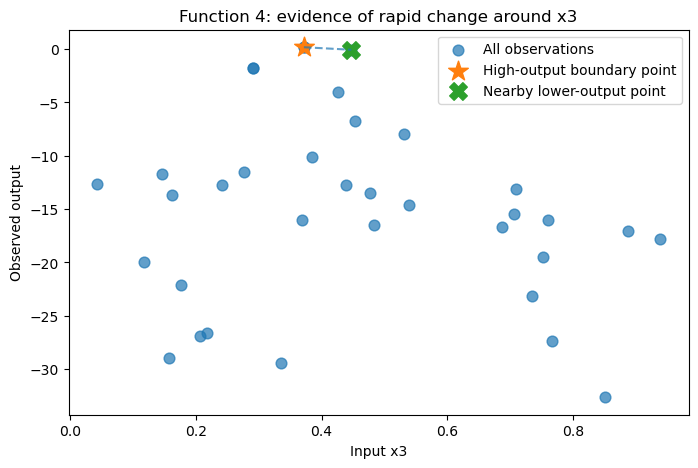

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(X[:, 2], Y, s=60, alpha=0.7, label="All observations")

week1 = np.array([0.370368, 0.421656, 0.371701, 0.447899])
week3 = np.array([0.379028, 0.410913, 0.447054, 0.442255])

plt.scatter(
    week1[2],
    0.17319018408919762,
    marker="*",
    s=220,
    label="High-output boundary point"
)

plt.scatter(
    week3[2],
    -0.06479142792096892,
    marker="X",
    s=160,
    label="Nearby lower-output point"
)

plt.plot(
    [week1[2], week3[2]],
    [0.17319018408919762, -0.06479142792096892],
    linestyle="--",
    alpha=0.7
)

plt.xlabel("Input x3")
plt.ylabel("Observed output")
plt.title("Function 4: evidence of rapid change around x3")
plt.legend()
plt.show()

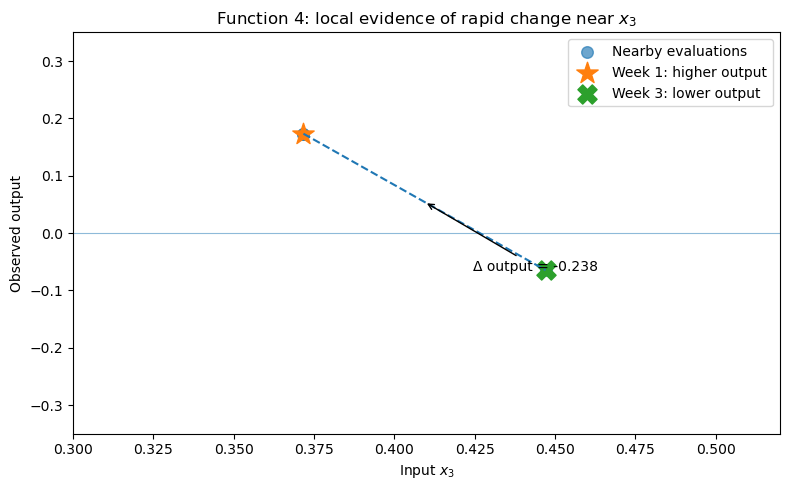

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Function 4 observations already stored in X and Y

week1_x3 = 0.371701
week1_y = 0.17319018408919762

week3_x3 = 0.447054
week3_y = -0.06479142792096892

# Keep only observations near the x3 region of interest
local_mask = (X[:, 2] >= 0.30) & (X[:, 2] <= 0.52)

plt.figure(figsize=(8, 5))

# Plot nearby observations only
plt.scatter(
    X[local_mask, 2],
    Y[local_mask],
    s=70,
    alpha=0.65,
    label="Nearby evaluations"
)

# Highlight the two key evaluations
plt.scatter(
    week1_x3,
    week1_y,
    marker="*",
    s=260,
    label="Week 1: higher output"
)

plt.scatter(
    week3_x3,
    week3_y,
    marker="X",
    s=190,
    label="Week 3: lower output"
)

# Connect the pair to emphasise the local change
plt.plot(
    [week1_x3, week3_x3],
    [week1_y, week3_y],
    linestyle="--",
    linewidth=1.5
)

# Annotate the output change
delta_y = week3_y - week1_y

mid_x = (week1_x3 + week3_x3) / 2
mid_y = (week1_y + week3_y) / 2

plt.annotate(
    f"Δ output = {delta_y:.3f}",
    xy=(mid_x, mid_y),
    xytext=(mid_x + 0.015, mid_y - 0.12),
    arrowprops={"arrowstyle": "->"}
)

plt.xlabel("Input $x_3$")
plt.ylabel("Observed output")
plt.title("Function 4: local evidence of rapid change near $x_3$")
plt.xlim(0.30, 0.52)
plt.ylim(-0.35, 0.35)
plt.axhline(0, linewidth=0.8, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()